In [6]:
!hostname

node114


In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Get participant data for current pipeline

In [2]:
!ls /mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/

elev_pilot	     pilot_azim_elev_exp		pilot_rel_dist_elev_v01
front_back_exp_v01   pilot_azim_elev_v00		preston_pilot
old_pilots	     pilot_rel_dist_azim_elev_v00	speaker_array_manifests
participant_001.csv  pilot_rel_dist_azim_elev_v01	two_talker_pilot_v01
participant_002.csv  pilot_rel_dist_azim_elev_v01_most


In [3]:
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/front_back_exp_v01/'
exp_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/front_back_exp_v01/'

results = list(Path(result_path).glob('*.csv'))
manifests = list(Path(exp_manifest_path).glob('*pilot_meta.pkl'))


global_manifest = pd.read_pickle('/om2/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/full_eval_trial_manifest_new_fnames_w_transcripts.pdpkl')


In [4]:
## Get all participant data into one df for analysis
def get_part_df(fname):
    part_df = pd.read_csv(fname)
    part_df = part_df[part_df.trial_type == 'dictionary-text'].reset_index(drop=True)
    part_df.trial_num = part_df.trial_num.astype(float).astype('int')
    # part_df['participant'] = fname.stem
    return part_df

def get_manifest_df(fname):
    manifest = pd.read_pickle(fname)
    manifest_df = pd.concat([pd.DataFrame(val.values()) for val in manifest.values()]).reset_index(drop=True)
    manifest_df['trial_num'] = manifest_df.index
    # unpack locations to azimuth and elevation 
    manifest_df['target_azim'] = manifest_df['target_loc'].apply(lambda x: x[0])
    manifest_df['target_elev'] = manifest_df['target_loc'].apply(lambda x: x[1])
    manifest_df['distractor_azim'] = manifest_df['distractor_loc'].apply(lambda x: x[0])
    manifest_df['distractor_elev'] = manifest_df['distractor_loc'].apply(lambda x: x[1])
    return manifest_df

def get_info_from_trial_dict(fname):
    manifest = pd.read_pickle(fname)
    trials = []
    for ix, trial in enumerate(manifest):
        trial_dict = {}
        trial_dict['target_azim'] = trial[0][0]
        trial_dict['target_elev'] = trial[0][1]
        trial_dict['distractor_azim'] = trial[1][0]
        trial_dict['distractor_elev'] = trial[1][1]
        trial_dict['target_word'] = Path(trial[3]).stem.split('_')[0]
        trial_dict['distractor_word'] = Path(trial[4]).stem.split('_')[0]
        trial_dict['trial_num'] = ix
        trials.append(trial_dict)
    manifest_df = pd.DataFrame(trials)
    return manifest_df

# Load global trial manifest df 


dfs = []
for ix, (fname, manifest) in enumerate(zip(results, manifests)):
    # try:
    # print(fname)
    # print(manifest)
    part_name = manifest.stem 
    part_df = get_part_df(fname)
    manifest_df = get_manifest_df(manifest)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on=['correct_response'], right_on=['target_word'], how='right')
    part_df = pd.merge(part_df, global_manifest[["gender_cond_td", 'word', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
        left_on=['sex_cond', 'correct_response', 'distractor_word'], right_on=['gender_cond_td', 'word', 'distractor_word'], how='left')
    part_df['participant'] = f"{fname.parent.stem}_{fname.stem}"

    dfs.append(part_df)
    
        # drop columns that are not useful for analysis
        # part_df.drop(['stimulus', 'trial_type', 'time_elapsed', 'internal_node_id', 'Unnamed: 0'], axis=1, inplace=True)
    # except Exception as e:
    #     print(e)
    #     print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs, ignore_index=True)

# add confusions
results_df['confusions'] = (results_df['response'] == results_df['distractor_word']).astype(int)

def same_diff_sex(string):
    target, distractor = string.split('_')
    if target == distractor:
        return 'same'
    else:
        return 'different'

results_df['gender_cond'] = results_df['sex_cond'].apply(same_diff_sex)

results_df['abs_target_azim'] = results_df['target_azim'].abs()

# make numerical columns same type
results_df['correct'] = results_df['correct'].astype('float')

# add adjusted accuracy and confusions 
response_words = results_df.response.values

target_transcripts = results_df.target_transcripts.values
distractor_transcripts = results_df.distractor_transcripts.values

adjusted_acc = np.array([int(response_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                             for response_word, target_transcript in zip(response_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(response_word in distractor_transcript)
                            if not isinstance(distractor_transcript, float) else np.nan
                             for response_word, distractor_transcript in zip(response_words, distractor_transcripts)
                              ])

results_df['adjusted_accuracy'] = adjusted_acc
results_df['adjusted_confusions'] = adjusted_confs

In [8]:
results_df.groupby('participant').correct.mean()

participant
front_back_exp_v01_participant_001    0.718085
front_back_exp_v01_participant_002    0.755319
Name: correct, dtype: float64

In [9]:
results_df.groupby('participant').adjusted_accuracy.mean()

participant
front_back_exp_v01_participant_001    0.739362
front_back_exp_v01_participant_002    0.771277
Name: adjusted_accuracy, dtype: float64

In [10]:
# # Helper function for reflecting points across circle midline (reflects angles across origin e.g. 170 -> 10; 180 -> 0; 190 -> 350)


# def reflect_point(original_angle, shift_by_360=False):
#     # Assuming the circle has a radius of 1 for simplicity
#     radius = 1
    
#     # Convert angle to radians
#     theta = np.radians(original_angle)
    
#     # Calculate the midpoint of the circle
#     midpoint_x = 0
#     midpoint_y = 0
    
#     # Calculate the coordinates of the point to be reflected
#     point_x = radius * np.cos(theta)
#     point_y = radius * np.sin(theta)
    
#     # Calculate the coordinates of the reflected point
#     reflected_x = -point_x
#     reflected_y = -point_y
    
#     # Convert reflected coordinates to angle
#     reflected_angle = np.degrees(np.arctan2(reflected_y, reflected_x))
#     if shift_by_360:
#         if isinstance(reflected_angle, np.ndarray):
#             reflected_angle[reflected_angle < 0] += 360
#         else:
#             if reflected_angle < 0:
#                 reflected_angle += 360
#     reflected_angle = np.rint(reflected_angle).astype('int')
#     return reflected_angle

In [11]:
grouped_results = results_df.groupby(['target_azim', 'target_elev', 'participant',
                                     'distractor_azim', 'distractor_elev',
                                     'azim_delta', 'elev_delta',
                                      'gender_cond']).agg({'correct':['mean', 'count'],
                                                            'confusions':['mean'],
                                                            'adjusted_accuracy':['mean'],
                                                            'adjusted_confusions':['mean']
                                                            }).reset_index()

# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]

grouped_results['abs_target_azim'] = grouped_results['target_azim'].abs()

grouped_results.loc[grouped_results.target_azim == -90, 'target_position'] = 'back'
grouped_results.loc[grouped_results.target_azim == 90, 'target_position'] = 'front'


grouped_results.loc[grouped_results.azim_delta.abs() > 90, "distractor_side"] = "opposite"
grouped_results.loc[grouped_results.azim_delta.abs() <= 90, "distractor_side"] = "same"

,trial_num_x,response,correct_response,correct,target_loc,distractor_loc,sex_cond,crossed,azim_delta,elev_delta,...,gender_cond_td,word,target_transcripts,distractor_transcripts,participant,confusions,gender_cond,abs_target_azim,adjusted_accuracy,adjusted_confusions
0,207.0,position,position,1.0,"(90, 0)","(0, 0)",male_female,0,-90,0,...,male_female,position,"[or, discontinued, position, of, assisted]","[but, their, concerns, were, dismissed, by, the]",front_back_exp_v01_participant_001,0,different,90,1.0,0.0
1,173.0,include,include,1.0,"(-90, 0)","(-70, 0)",male_male,0,20,0,...,male_male,include,"[the, augmented, features, include, line, numb...","[the, author, of, several, books, and, lecture...",front_back_exp_v01_participant_001,0,same,90,1.0,0.0
2,222.0,built,german,0.0,"(90, 0)","(70, 0)",female_female,0,-20,0,...,female_female,german,"[the, design, of, the, german, church, building]","[facility, in, whites, district, however]",front_back_exp_v01_participant_001,0,same,90,0.0,0.0
3,79.0,became,became,1.0,"(90, 0)","(60, 0)",female_male,0,-30,0,...,female_male,became,"[patterson, became, the, cradle, of, the]","[caesar, on, the, level, of, such, military]",front_back_exp_v01_participant_001,0,different,90,1.0,0.0
4,64.0,larger,larger,1.0,"(-90, 0)","(90, 0)",male_female,0,180,0,...,male_female,larger,"[with, the, much, larger, enceladus]","[larger, than, that, of, a, regular, sitcom]",front_back_exp_v01_participant_001,0,different,90,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,181.0,formed,forms,0.0,"(90, 40)","(90, 40)",male_male,0,0,0,...,male_male,forms,"[as, both, forms, as, alternative]","[to, questions, to, government, ministers]",front_back_exp_v01_participant_002,0,same,90,0.0,0.0
516,152.0,front,front,1.0,"(90, 40)","(-90, 40)",female_female,0,-180,0,...,female_female,front,"[approaching, cold, front]","[towns, and, cities, were, chartered]",front_back_exp_v01_participant_002,0,same,90,1.0,0.0
517,228.0,future,future,1.0,"(90, -20)","(-90, 40)",female_male,0,-180,60,...,female_male,future,"[some, for, your, future, eugenics, ward]","[only, after, it, has, received]",front_back_exp_v01_participant_002,0,different,90,1.0,0.0
518,31.0,should,should,1.0,"(90, -20)","(-90, -20)",male_female,0,-180,0,...,male_female,should,"[it, orders, that, he, should, not, be, harmed]","[large, mixed, flocks, with]",front_back_exp_v01_participant_002,0,different,90,1.0,0.0


In [13]:
grouped_results.distractor_side.value_counts()

same        56
opposite    48
Name: distractor_side, dtype: int64

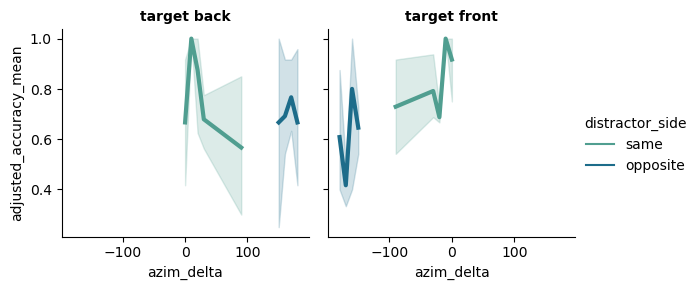

In [14]:
g = sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) & (grouped_results.distractor_elev == 0)],
            x="azim_delta", y="adjusted_accuracy_mean", col="target_position", hue="distractor_side",
            kind="line", palette="crest", linewidth=3, zorder=5,
            height=3, aspect=1, legend=True,
        )

g.set_titles("target {col_name}", fontweight="bold")
# g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0., 1.1, 0.2))


In [ ]:
to_plot = results_df[(results_df.target_elev == 0) & (results_df.distractor_elev == 0)].copy()
to_plot = to_plot[to_plot.target_azim.isin([90, -90])]
to_plot['abs_azim_delta'] = to_plot['azim_delta'].abs()


# to_plot['abs_distractor_delta'] = to_plot['azim_delta'].abs()
# to_plot.loc[to_plot['abs_distractor_delta'] > 90, 'abs_distractor_delta'] = 180 - to_plot['abs_distractor_delta']

g = sns.relplot(data=to_plot,
            x="abs_azim_delta", y="adjusted_accuracy", hue='target_azim', #hue="distractor_side",
            kind="line", palette="Set2", linewidth=3, zorder=5, #style='gender_cond',
            height=3, aspect=1.2, legend=True,
        )

# change legend titles 
g._legend.set_title("Target position")
new_labels = ['Front', 'Back']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# move legened to lower left of figure 
g._legend.set_bbox_to_anchor((0.4, 0.3))

# g.axes[0,0].set_title("Target behind listener", fontweight="bold")
# g.axes[0,1].set_title("Target in front of listener", fontweight="bold")
g.set(xticks=np.arange(0, 181, 30), yticks=np.arange(0., 1.1, 0.2))
g.set(xlabel="Distractor separation in azimuth ($\degree$)", ylabel="Accuracy")

In [77]:
results_df.groupby(['target_azim', 'distractor_azim']).target_loc.count()

target_azim  distractor_azim
-90          -90                 20
             -80                 20
             -70                 20
             -60                 20
              0                  20
              60                 20
              70                 20
              80                 20
              90                 20
 90          -90                100
             -80                 20
             -70                 20
             -60                 20
              0                  20
              60                 20
              70                 20
              80                 20
              90                100
Name: target_loc, dtype: int64

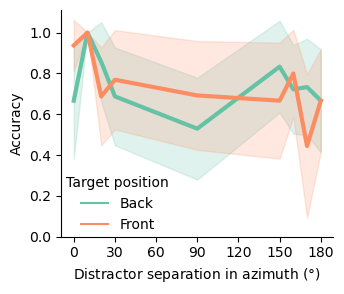

In [80]:
to_plot = results_df[(results_df.target_elev == 0) & (results_df.distractor_elev == 0)].copy()
to_plot = to_plot[to_plot.target_azim.isin([90, -90])]
to_plot['abs_azim_delta'] = to_plot['azim_delta'].abs()


# to_plot['abs_distractor_delta'] = to_plot['azim_delta'].abs()
# to_plot.loc[to_plot['abs_distractor_delta'] > 90, 'abs_distractor_delta'] = 180 - to_plot['abs_distractor_delta']

g = sns.relplot(data=to_plot,
            x="abs_azim_delta", y="adjusted_accuracy", hue='target_azim', #hue="distractor_side",
            kind="line", palette="Set2", linewidth=3, zorder=5, #style='gender_cond',
            height=3, aspect=1.2, legend=True, errorbar = ('se', 2),
        )

# change legend titles 
g._legend.set_title("Target position")
new_labels = ['Back', 'Front']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# move legened to lower left of figure 
g._legend.set_bbox_to_anchor((0.4, 0.3))

# g.axes[0,0].set_title("Target behind listener", fontweight="bold")
# g.axes[0,1].set_title("Target in front of listener", fontweight="bold")
g.set(xticks=np.arange(0, 181, 30), yticks=np.arange(0., 1.1, 0.2))
g.set(xlabel="Distractor separation in azimuth ($\degree$)", ylabel="Accuracy")

/tmp/ipykernel_3763830/1302014372.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(data=to_plot,


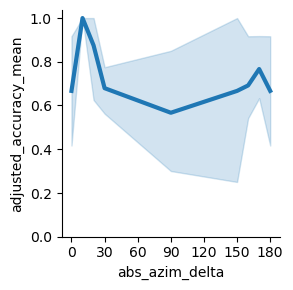

In [ ]:
to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.distractor_elev == 0)].copy()
to_plot = to_plot[to_plot.target_azim == 90]
to_plot['abs_azim_delta'] = to_plot['azim_delta'].abs()


# to_plot['abs_distractor_delta'] = to_plot['azim_delta'].abs()
# to_plot.loc[to_plot['abs_distractor_delta'] > 90, 'abs_distractor_delta'] = 180 - to_plot['abs_distractor_delta']

g = sns.relplot(data=to_plot,
            x="abs_azim_delta", y="adjusted_accuracy_mean",# hue='distractor_size',#hue="distractor_side",
            kind="line", palette="crest", linewidth=3, zorder=5, #style='gender_cond',
            height=3, aspect=1, legend=True,
        )

g.set_titles("target {col_name}", fontweight="bold")
g.set(xticks=np.arange(0, 181, 30), yticks=np.arange(0., 1.1, 0.2))


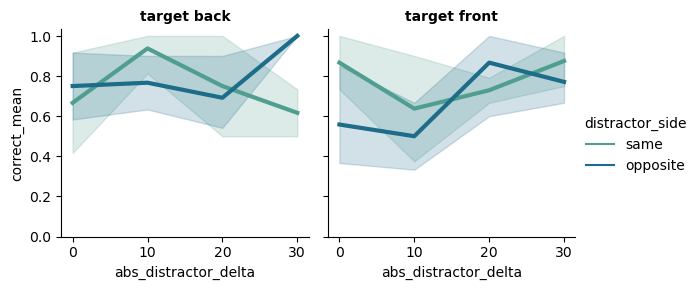

In [81]:
to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.distractor_elev == 0)].copy()
to_plot = to_plot[to_plot.azim_delta.abs() != 90]
to_plot['abs_distractor_delta'] = to_plot['azim_delta'].abs()
to_plot.loc[to_plot['abs_distractor_delta'] > 90, 'abs_distractor_delta'] = 180 - to_plot['abs_distractor_delta']

g = sns.relplot(data=to_plot,
            x="abs_distractor_delta", y="correct_mean", col='target_position', hue="distractor_side",
            kind="line", palette="crest", linewidth=3, zorder=5, #style='gender_cond',
            height=3, aspect=1, legend=True,
        )

g.set_titles("target {col_name}", fontweight="bold")
g.set(xticks=np.arange(0, 31, 10), yticks=np.arange(0., 1.1, 0.2))


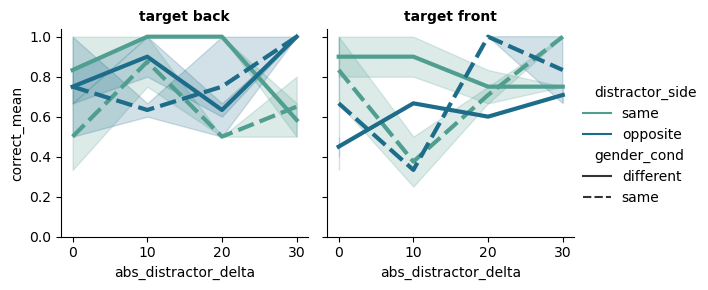

In [ ]:
to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.distractor_elev == 0)].copy()
to_plot = to_plot[to_plot.azim_delta.abs() != 90]
to_plot['abs_distractor_delta'] = to_plot['azim_delta'].abs()
to_plot.loc[to_plot['abs_distractor_delta'] > 90, 'abs_distractor_delta'] = 180 - to_plot['abs_distractor_delta']

g = sns.relplot(data=to_plot,
            x="abs_distractor_delta", y="correct_mean", col='target_position', hue="distractor_side",
            kind="line", palette="crest", linewidth=3, zorder=5, style='gender_cond',
            height=3, aspect=1, legend=True,
        )

g.set_titles("target {col_name}", fontweight="bold")
g.set(xticks=np.arange(0, 31, 10), yticks=np.arange(0., 1.1, 0.2))


### Plot elevation trials 

In [93]:
to_plot = grouped_results[grouped_results.target_elev != 0 ].copy()
to_plot

,target_azim,target_elev,participant,distractor_azim,distractor_elev,azim_delta,elev_delta,gender_cond,correct_mean,correct_sem,confusions_mean,confusions_sem,adjusted_accuracy_mean,adjusted_accuracy_sem,adjusted_confusions_mean,adjusted_confusions_sem,abs_target_azim,target_position,distractor_side
36,90,-20,front_back_exp_v01_participant_001,-90,-20,-180,0,different,0.250000,0.250000,0.0,0.0,0.500000,0.288675,0.0,0.0,90,front,opposite
37,90,-20,front_back_exp_v01_participant_001,-90,-20,-180,0,same,0.750000,0.250000,0.0,0.0,0.750000,0.250000,0.0,0.0,90,front,opposite
38,90,-20,front_back_exp_v01_participant_001,-90,40,-180,60,different,0.833333,0.166667,0.0,0.0,0.833333,0.166667,0.0,0.0,90,front,opposite
39,90,-20,front_back_exp_v01_participant_001,-90,40,-180,60,same,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,90,front,opposite
40,90,-20,front_back_exp_v01_participant_001,90,-20,0,0,different,0.666667,0.333333,0.0,0.0,0.666667,0.333333,0.0,0.0,90,front,same
41,90,-20,front_back_exp_v01_participant_001,90,-20,0,0,same,0.800000,0.200000,0.0,0.0,0.800000,0.200000,0.0,0.0,90,front,same
42,90,-20,front_back_exp_v01_participant_001,90,40,0,60,different,0.750000,0.250000,0.0,0.0,0.750000,0.250000,0.0,0.0,90,front,same
43,90,-20,front_back_exp_v01_participant_001,90,40,0,60,same,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,90,front,same
44,90,-20,front_back_exp_v01_participant_002,-90,-20,-180,0,different,1.000000,0.000000,0.0,0.0,1.000000,0.000000,0.0,0.0,90,front,opposite
45,90,-20,front_back_exp_v01_participant_002,-90,-20,-180,0,same,0.750000,0.250000,0.0,0.0,1.000000,0.000000,0.0,0.0,90,front,opposite


In [ ]:
to_plot

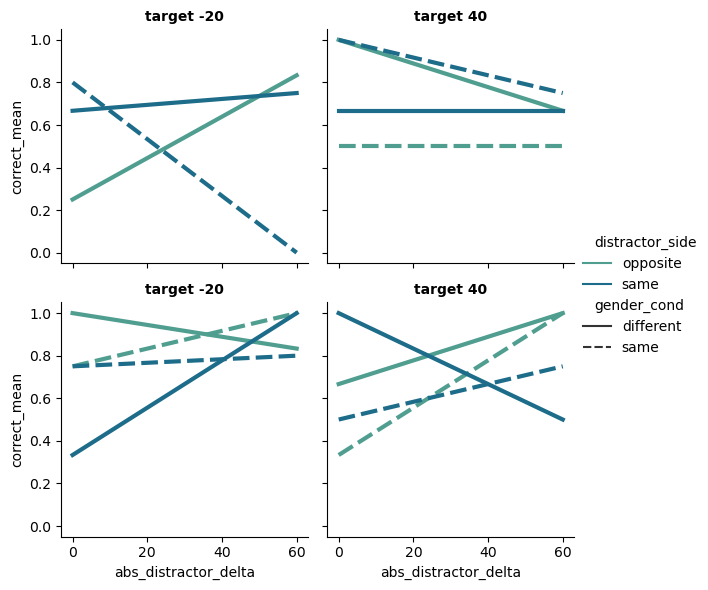

In [115]:
to_plot = grouped_results[grouped_results.target_elev != 0 ].copy()
to_plot['abs_distractor_delta'] = to_plot['elev_delta'].abs()

g = sns.relplot(data=to_plot,
            x="abs_distractor_delta", y="correct_mean", col='target_elev', hue="distractor_side",
            kind="line", palette="crest", linewidth=3, zorder=5,  style='gender_cond',   
            row='participant',
            height=3, aspect=1, legend=True,)

g.set_titles("target {col_name}", fontweight="bold")
g.set(xticks=np.arange(0, 61, 20), yticks=np.arange(0., 1.1, 0.2))
